# 3. Model Evaluation

Test metrics, confusion matrix, ROC curve

In [3]:
# ============================================================================
# 3_Evaluation.ipynb - Evaluate ResNet18 Performance on Test Set
# ============================================================================
# Purpose: Generate evaluation metrics, confusion matrix, ROC curve
# Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
# Output: Visualizations + evaluation_results.json
# ============================================================================

# Import libraries
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn metrics: untuk classification evaluation
from sklearn.metrics import (
    confusion_matrix,         # CM untuk TP, FP, FN, TN
    classification_report,    # Detailed metrics (precision, recall, F1)
    roc_curve,               # ROC curve data
    auc,                     # Area Under Curve
    accuracy_score           # Overall accuracy
)
import json

# Setup device (GPU atau CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Output folder untuk hasil evaluasi
logs_path = Path('logs')
logs_path.mkdir(parents=True, exist_ok=True)

Device: cuda


## 1. Load Model & Test Data

In [4]:
# ============================================================================
# Step 1: Load Trained ResNet18 Model
# ============================================================================

MODEL_NAME = 'resnet18'

# Build model architecture (harus sama persis dengan notebook training)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

# Candidate model paths (prioritas final model, fallback best checkpoint)
candidate_paths = [
    Path('resnet18_final_best_practice.pth'),
    Path('resnet18_best.pth')
]

model_path = None
for p in candidate_paths:
    if p.exists():
        model_path = p
        break

if model_path is None:
    raise FileNotFoundError(
        "Model file not found. Expected one of: "
        "resnet18_final_best_practice.pth or resnet18_best.pth"
    )

print(f"Loading model from: {model_path}")
checkpoint = torch.load(str(model_path), map_location=device)

# Support 2 formats:
# 1) state_dict langsung (resnet18_final_best_practice.pth)
# 2) checkpoint dict dengan key model_state_dict (resnet18_best.pth)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

# Move model ke device dan set evaluation mode
model = model.to(device)
model.eval()

print("✅ Model weights loaded successfully")
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"   Path: {model_path}")
print(f"   Device: {device}")

Loading model from: resnet18_final_best_practice.pth
✅ Model weights loaded successfully
✅ Model loaded: resnet18
   Path: resnet18_final_best_practice.pth
   Device: cuda


In [5]:
# ============================================================================
# Step 2: Load Test Data & Create DataLoader
# ============================================================================
# Load test set dari data_processed_original_only (sama pipeline dengan training)

data_path = Path('data_processed_original_only')
assert data_path.exists(), f"Data directory not found: {data_path}"

# Load test arrays
X_test = np.load(data_path / 'test' / 'images.npy')
y_test = np.load(data_path / 'test' / 'labels.npy')

# ImageNet normalization (sama seperti training)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

X_test_norm = np.zeros_like(X_test)
for i in range(3):
    X_test_norm[..., i] = (X_test[..., i] - IMAGENET_MEAN[i]) / IMAGENET_STD[i]

# Convert ke tensor format PyTorch: (N, H, W, C) -> (N, C, H, W)
X_test_tensor = torch.from_numpy(X_test_norm.transpose(0, 3, 1, 2)).float()
y_test_tensor = torch.from_numpy(y_test).long()

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"✅ Test data loaded from: {data_path / 'test'}")
print(f"   Test set size: {len(test_dataset)} images")
print(f"   Test DataLoader created: {len(test_loader)} batches")

✅ Test data loaded from: data_processed_original_only\test
   Test set size: 119 images
   Test DataLoader created: 4 batches


## 2. Test Set Predictions

In [6]:
# ============================================================================
# Step 3: Generate Predictions on Test Set
# ============================================================================
# Collect predictions dari semua batches
all_preds = []      # Predicted class (0 atau 1)
all_probs = []      # Softmax probabilities untuk setiap class
all_labels = []     # True labels

# torch.no_grad(): Disable gradient calculation (faster, less memory)
with torch.no_grad():
    for images, labels in test_loader:
        # Move to GPU
        images = images.to(device)
        
        # Forward pass: get logits
        outputs = model(images)
        
        # Convert logits -> probabilities menggunakan softmax
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        # Get predicted class (argmax of logits)
        _, preds = torch.max(outputs, 1)
        
        # Collect results
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print(f"Predictions: {all_preds.shape}")
print(f"Probabilities: {all_probs.shape}")
print(f"Labels: {all_labels.shape}")

Predictions: (119,)
Probabilities: (119, 2)
Labels: (119,)


## 3. Classification Metrics

In [7]:
# ============================================================================
# Step 4: Calculate Classification Metrics
# ============================================================================
# Metrics untuk binary classification evaluation

# Define class names
class_names = ['Jernih (Clear)', 'Keruh (Turbid)']

# Overall accuracy: (TP + TN) / Total
accuracy = accuracy_score(all_labels, all_preds)

# Detailed classification report
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(all_labels, all_preds, target_names=class_names))
print("="*70)


CLASSIFICATION REPORT
                precision    recall  f1-score   support

Jernih (Clear)       0.93      0.92      0.92        72
Keruh (Turbid)       0.88      0.89      0.88        47

      accuracy                           0.91       119
     macro avg       0.90      0.91      0.90       119
  weighted avg       0.91      0.91      0.91       119



## 4. Confusion Matrix

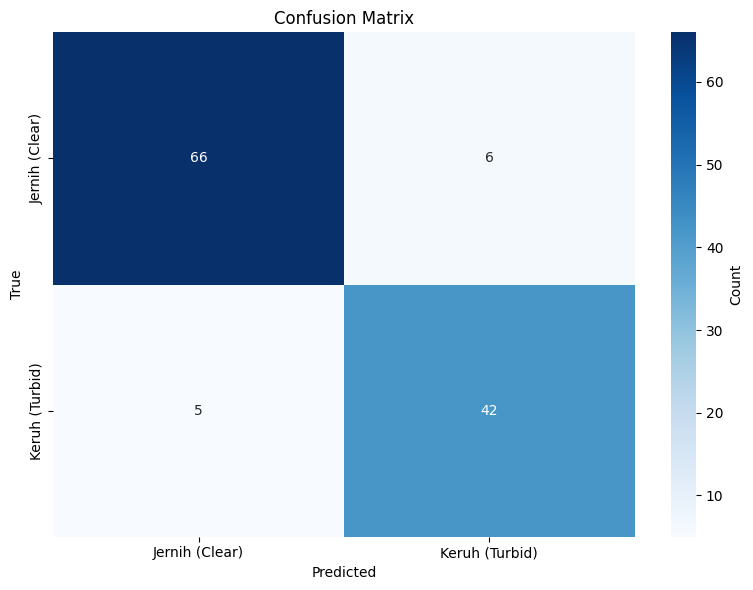


CONFUSION MATRIX
                Predicted
                Clear    Turbid
True Clear        66      6      
     Turbid       5       42     


In [8]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
plt.tight_layout()

logs_path = Path('logs')
plt.savefig(logs_path / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)
print(f"                Predicted")
print(f"                Clear    Turbid")
print(f"True Clear        {cm[0,0]:<7} {cm[0,1]:<7}")
print(f"     Turbid       {cm[1,0]:<7} {cm[1,1]:<7}")

Misclassified: 11 / 119


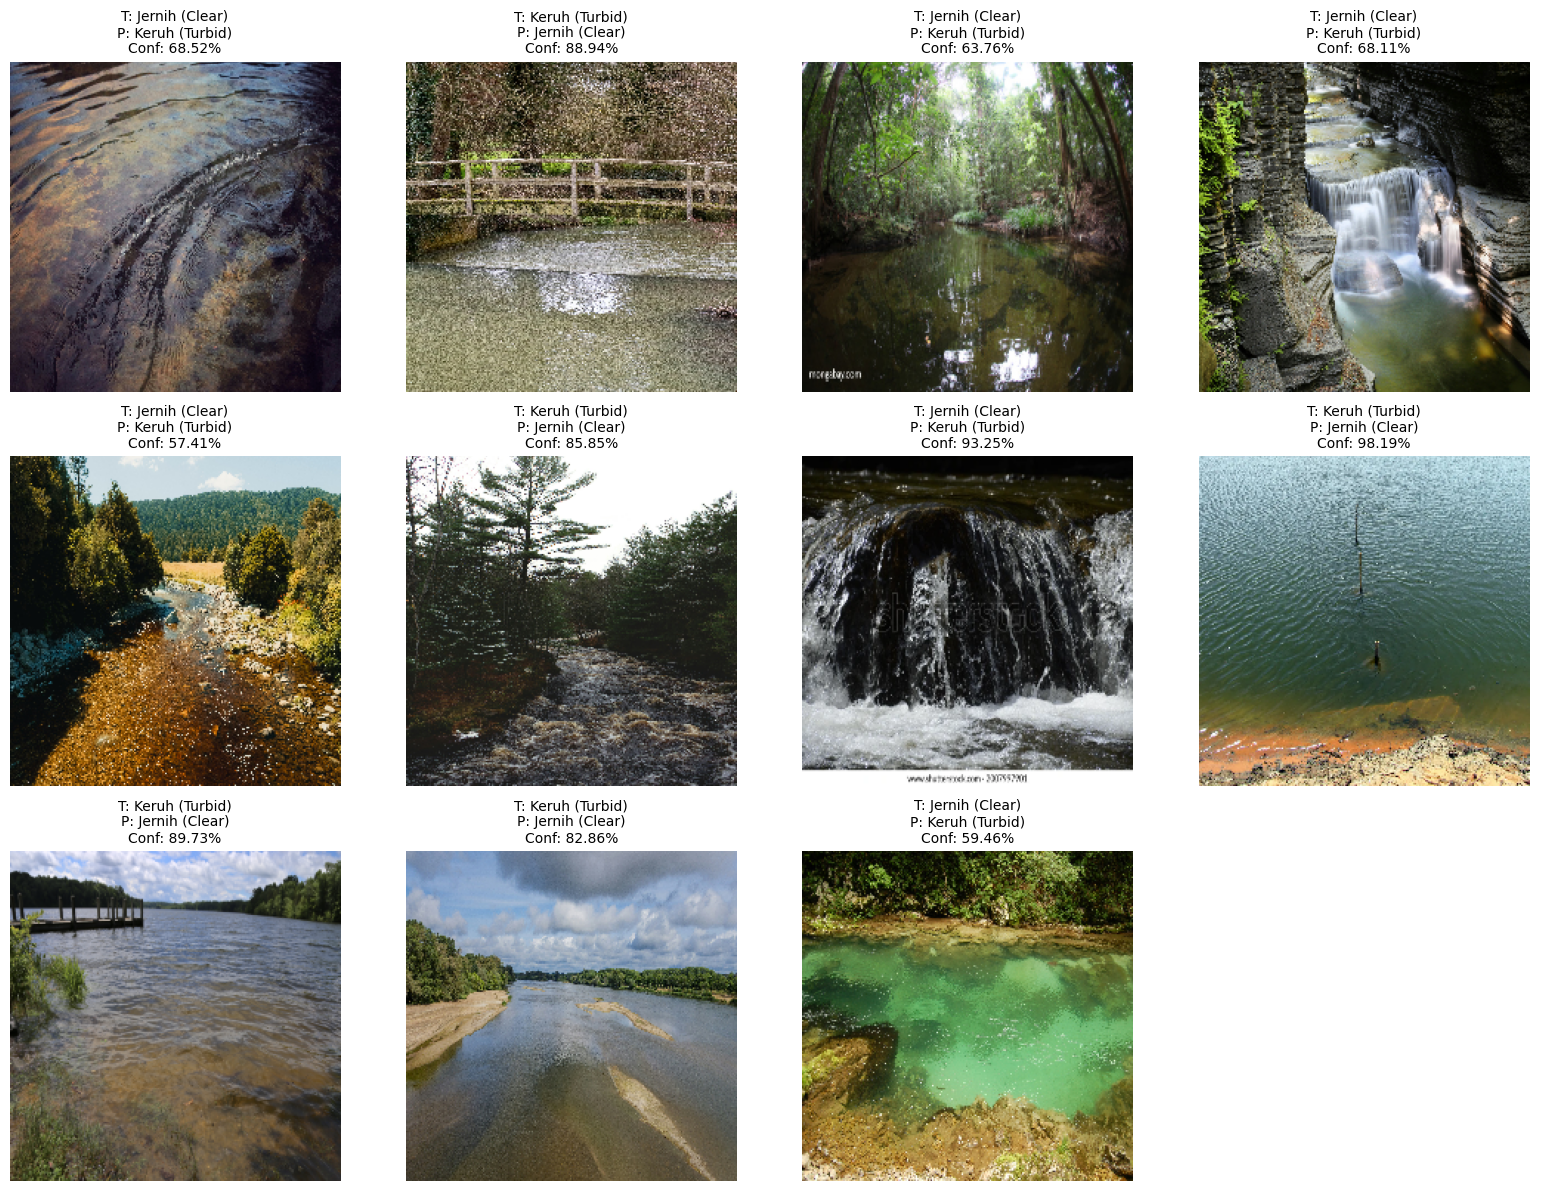

Saved: logs\misclassified_samples.png


In [9]:
# ============================================================================
# Misclassified Samples (Image + True/Pred + Confidence)
# ============================================================================
mis_idx = np.where(all_preds != all_labels)[0]
print(f"Misclassified: {len(mis_idx)} / {len(all_labels)}")

max_show = 12
if len(mis_idx) == 0:
    print("No misclassified samples.")
else:
    n_show = min(max_show, len(mis_idx))
    cols = 4
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, mis_idx[:n_show]):
        img = X_test[idx]
        true_label = class_names[int(all_labels[idx])]
        pred_label = class_names[int(all_preds[idx])]
        conf = float(all_probs[idx, int(all_preds[idx])])
        ax.imshow(img)
        ax.set_title(f"T: {true_label}\nP: {pred_label}\nConf: {conf:.2%}", fontsize=10)
        ax.axis('off')

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(logs_path / 'misclassified_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {logs_path / 'misclassified_samples.png'}")

## 5. ROC Curve

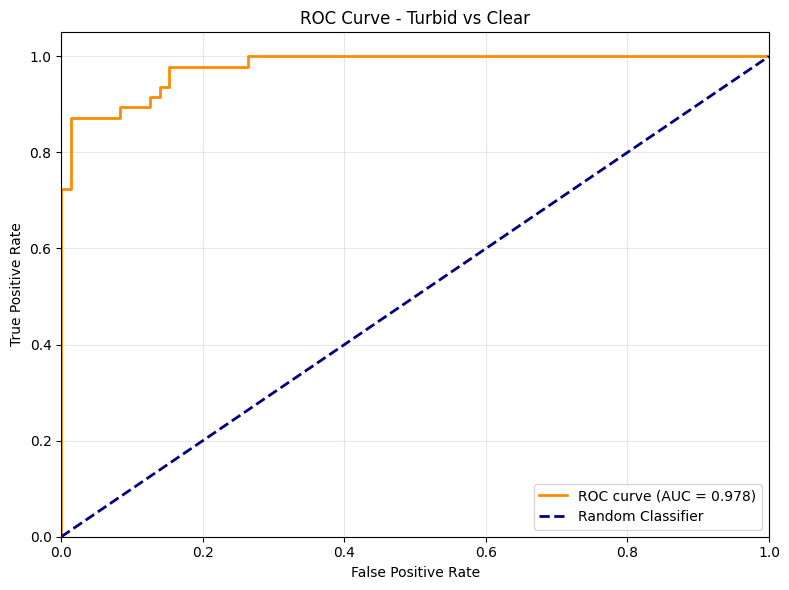


ROC AUC Score: 0.9784


In [ ]:
# ROC curve (one-vs-rest for class 1 - Turbid)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Turbid vs Clear')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(logs_path / 'roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")

## 6. Save Evaluation Results

In [ ]:
# Save metrics
evaluation_results = {
    'overall_accuracy': float(accuracy),
    'roc_auc': float(roc_auc),
    'confusion_matrix': cm.tolist(),
    'per_class_metrics': report,
    'test_size': len(all_labels),
    'class_names': class_names,
    'model': 'resnet18',
    'dataset': 'data_processed_original_only'
}

eval_file = logs_path / 'evaluation_results.json'
with open(eval_file, 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print(f"\n✅ Evaluation results saved to: {eval_file}")


✅ Evaluation results saved to: logs\evaluation_results.json


## 7. Summary

In [ ]:
print("\n" + "="*70)
print("EVALUATION SUMMARY")
print("="*70)
print(f"Model: ResNet18 (Pre-trained ImageNet + Fine-tuned)")
print(f"Test Set Size: {len(all_labels)} images")
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"\nOutputs:")
print(f"  - Confusion matrix: {logs_path / 'confusion_matrix.png'}")
print(f"  - ROC curve: {logs_path / 'roc_curve.png'}")
print(f"  - Metrics JSON: {eval_file}")
print("="*70)


EVALUATION SUMMARY
Model: ResNet18 (Pre-trained ImageNet + Fine-tuned)
Test Set Size: 119 images
Overall Accuracy: 90.76%
ROC AUC Score: 0.9784

Outputs:
  - Confusion matrix: logs\confusion_matrix.png
  - ROC curve: logs\roc_curve.png
  - Metrics JSON: logs\evaluation_results.json
